In [ ]:
%%capture

import re

import torch; v = re.match(r'[\d]{1,}\.[\d]{1,}', str(torch.__version__)).group(0)
xformers = 'xformers==' + {'2.10':'0.0.34','2.9':'0.0.33.post1','2.8':'0.0.32.post2'}.get(v, "0.0.34")
%pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
%pip install --no-deps unsloth_zoo bitsandbytes accelerate {xformers} peft trl triton unsloth
%pip install --no-deps --upgrade "torchao>=0.16.0"
%pip install --no-deps transformers==5.5.0 "tokenizers>=0.22.0,<=0.23.0"
%pip install torchcodec

import torch; torch._dynamo.config.recompile_limit = 64;

%pip install --no-deps --upgrade timm  # For Gemma 4 vision/audio

%pip install evaluate rouge_score

import os
import gdown
import zipfile

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 22.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 84.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 18.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.3/199.3 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 123.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 5.5 MB/s eta 0:00:00:00:01
   ━

### load ds

In [2]:
import os
import gdown
import zipfile

file_id = "1WhOgsEWmLSnEG2-K8R2n_hogFLGPkI8I"
download_url = f"https://drive.google.com/uc?id={file_id}"

zip_path = "/content/mredditsum.zip"
extract_dir = "/content/mredditsum_dataset"

# Download if not already downloaded
if not os.path.exists(zip_path):
    print("Downloading mRedditSum dataset...")
    gdown.download(download_url, zip_path, quiet=False)
else:
    print("ZIP file already exists. Skipping download.")

# Extract the ZIP file
if not os.path.exists(extract_dir):
    print("Extracting files...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("Extraction complete.")
else:
    print("Extracted folder already exists. Skipping extraction.")

print(f"Dataset extracted to: {extract_dir}")

Downloading...
From (original): https://drive.google.com/uc?id=1WhOgsEWmLSnEG2-K8R2n_hogFLGPkI8I
From (redirected): https://drive.google.com/uc?id=1WhOgsEWmLSnEG2-K8R2n_hogFLGPkI8I&confirm=t&uuid=d034c457-053e-4fe4-94a8-63144042e466
To: /content/mredditsum.zip
100%|██████████| 28.3M/28.3M [00:00<00:00, 66.8MB/s]


Extracting files...
Extraction complete.
Dataset extracted to: /content/mredditsum_dataset


In [3]:
from datasets import Dataset, DatasetDict
import json

data_dir = extract_dir
splits = {
    # "train": {"src": "train_processed_src.txt", "tgt": "train_processed_tgt.txt", "raw": "train.json"},
    # "val":   {"src": "val_processed_src.txt",   "tgt": "val_processed_tgt.txt", "raw": "val.json"},
    "test":  {"src": "test_processed_src.txt",  "tgt": "test_processed_tgt.txt", "raw": "test.json"},
}

dataset_dict = {}
for split_name, files in splits.items():
    src_path = os.path.join(data_dir + '/downloadable_data/preprocessed/', files["src"])
    tgt_path = os.path.join(data_dir + '/downloadable_data/preprocessed/', files["tgt"])
    raw_path = os.path.join(data_dir + '/downloadable_data/raw/', files["raw"])
    
    # Read source and target files line by line
    with open(src_path, "r", encoding="utf-8") as f:
        src_lines = f.read().strip().split("\n")
    with open(tgt_path, "r", encoding="utf-8") as f:
        tgt_lines = f.read().strip().split("\n")
    with open(raw_path, "r", encoding="utf-8") as f:
        raw_lines = json.load(f)["threads"]
        
    src_lines = [t[7:] for t in src_lines]
    tgt_lines = [t[7:] for t in tgt_lines]
    url_lines = [item["url"] for item in raw_lines]
    subreddit_lines = [item["subreddit"] for item in raw_lines]
    
    # Make sure we have matching pairs
    error_msg = f"Mismatch in {split_name}: {len(src_lines)} src vs {len(tgt_lines)} tgt vs raw {len(raw_lines)}"
    assert len(src_lines) == len(tgt_lines) == len(raw_lines) == len(url_lines) == len(subreddit_lines), error_msg
    
    # Create a Hugging Face Dataset for this split
    dataset_dict[split_name] = Dataset.from_dict({
        "source": src_lines,
        "target": tgt_lines,
        "url": url_lines,
        "subreddit": subreddit_lines
    })

# Combine into a single DatasetDict
mredditsum = DatasetDict(dataset_dict)
print(mredditsum)

DatasetDict({
    test: Dataset({
        features: ['source', 'target', 'url', 'subreddit'],
        num_rows: 152
    })
})


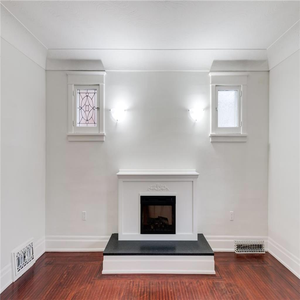

In [5]:
from PIL import Image
from io import BytesIO
import os
from IPython.display import display
import requests

def download_image(url):
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    
    img = Image.open(BytesIO(r.content))
    if img.mode != "RGB":
        img = img.convert("RGB")
    
    img = img.resize((300, 300), Image.Resampling.LANCZOS)
    
    return img

download_image(mredditsum['test'][0]['url'])

In [ ]:
from unsloth.chat_templates import standardize_data_formats

test_ds = standardize_data_formats(mredditsum['test'])

N_SAMPLES = 1 # 30
test_ds_part = test_ds.select(range(N_SAMPLES))

test_ds[0]

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


{'source': 'Original Post: Help with Small living room User 1: Please do not put your TV over this fireplace. Giant black rectangle there would just ruin that wall, detract from the stained glass, and generally look out of place.  OP: 100% agreed!! Was thinking maybe in the corner User 1: I’d try that! Your place looks adorable, btw.  OP: We’re moving into our first house - a 1920s craftsman style home (I think). This is our new living room and I’d love some help figuring out how to lay it out. For furniture we basically have a couch and a flatscreen tv so far and we love a modern eclectic style. I’ll try to add another angle if I can figure out how to add more pics. Edit: damnit I can’t figure out how to add another image  User 2: On both sides of the fireplace, I would def add two matching shelves or better yet, matching cabinets or drawer chests (hides clutter).  Just high enough so that the air flow from the register (?) on the right isn’t blocked.   Orient your couch facing one of

In [7]:
from tqdm import tqdm

url2file = {}

for url in tqdm(list(test_ds['url'])):
    try:
        image = download_image(url)
        url2file[url] = image
    except:
        continue

 91%|█████████▏| 139/152 [00:53<00:04,  2.82it/s]/usr/local/lib/python3.13/dist-packages/PIL/Image.py:3452: DecompressionBombWarning: Image size (108000000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
100%|██████████| 152/152 [00:59<00:00,  2.56it/s]


In [8]:
print('before', len(test_ds))

test_ds = test_ds.filter(lambda example: example["url"] in url2file)

print('after', len(test_ds))

before 152


Filter:   0%|          | 0/152 [00:00<?, ? examples/s]

after 128


### load models

In [9]:
from unsloth import FastModel

MODEL_NAME = 'unsloth/gemma-4-E2B-it'

MAX_SEQ_LEN = 1024

model, tokenizer = FastModel.from_pretrained(
    model_name = MODEL_NAME,
    dtype = None,
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit = True,
    full_finetuning = False,
)

ft_model, ft_tokenizer = FastModel.from_pretrained(
    model_name = "pameydorke/redred-gemma-4-E2B-it-lora",
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit = True,
)

==((====))==  Unsloth 2026.9.5: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma4 won't work! Using float32.


Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

==((====))==  Unsloth 2026.9.5: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma4 won't work! Using float32.


ValueError: Some modules are dispatched on the CPU or the disk. Make sure you have enough GPU RAM to fit the quantized model. If you want to dispatch the model on the CPU or the disk while keeping these modules in 32-bit, you need to set `llm_int8_enable_fp32_cpu_offload=True` and pass a custom `device_map` to `from_pretrained`. Check https://huggingface.co/docs/transformers/main/en/main_classes/quantization#offload-between-cpu-and-gpu for more details. 

### generate summaries

In [ ]:
def generate_summary(model, tokenizer, row):
    content_text = f'''Please write a short summary of the following Reddit post from \"{row["subreddit"]}\" subreddit:
"{row["source"]}"
Just plain summary without introductory text, titles, subtitles, lists, suggestions
'''

    messages = [
        {
            "role": "user",
            "content": [
                { "type": "image", "image": url2file[row["url"]] },
                {
                    "type" : "text",
                    "text" : content_text,
                }
            ]
        },
    ]
    
    inputs = tokenizer.apply_chat_template(
        messages,
        add_generation_prompt = True,
        tokenize = True,
        return_dict = True,
        return_tensors = "pt",
    ).to("cuda")
    
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens = 128,
            temperature = 1.0, top_p = 0.95, top_k = 64, # recommended by devs
            use_cache = True,
        )
        
    generated_text = tokenizer.decode(
        outputs[0][inputs.input_ids.shape[1]:], skip_special_tokens=True
    ).strip()

    return generated_text

SOURCE_COL = "source"
REF_COL = "target"

records = []
for row in test_ds:
    source = row[SOURCE_COL]
    reference = row[REF_COL]
    records.append({
        "user_input": source,   # RAGAS naming convention
        "reference": reference,
        "base_response": generate_summary(model, tokenizer, row),
        "ft_response":   generate_summary(ft_model, ft_tokenizer, row),
    })

print("Sample base summary:\n", records[0]["base_response"])
print("\nSample fine-tuned summary:\n", records[0]["ft_response"])